# AGFB Generator Visual Check

This notebook is a small visual smoke test for the analytic gradient field generators. It is meant to answer three questions quickly. First, can each generator be called with a short, readable example. Second, does the returned intensity image look like the intended synthetic field. Third, do the returned gradient channels have the expected shape and sign pattern.

The simplest pattern is `frame = generator(...)`, then `show_image(frame.I[0])`. Each generator returns `frame.I` with shape `(B, H, W)` and `frame.g` with shape `(B, 2, H, W)`. The first gradient channel is `g_x`, and the second gradient channel is `g_y`.

## Setup

Run this cell first. It imports the generators, imports the notebook display helpers, fixes a shared image size, and initializes the notebook display settings. Keeping this setup in one cell makes the later examples short enough that the generator call itself stays visible.

In [ ]:
# math is used only to write angles in degrees before converting to radians.
import math

# torch is used for batched inputs, coefficient tensors, and tensor checks.
import torch

# Each generator returns a Frame with an intensity image and analytic gradients.
from agfb_generators import (
    curved_arc,
    gaussian_blob,
    gaussian_ridge,
    hard_step,
    polynomial,
    sinusoid,
    smoothed_bar,
    smoothed_step,
)

# Notebook helpers keep display setup and color mapping out of the examples.
from agfb_generators.notebook import set_color_scheme, setup_notebook, show_color_scheme, show_image

# All examples use the same canvas so the results are easy to compare.
H, W = 160, 160  # Height and width of the generated images.
setup_notebook(height=H, width=W)

## Color Scheme

This block defines the colors used by `show_image`. The keys describe the kind of image being displayed. `intensity` is for scalar field values, `magnitude` is for nonnegative gradient magnitudes, `signed` is for values that can be negative or positive, and `mask` is for binary or categorical overlays. The commented blocks show complete replacement schemes, so changing the notebook colors only requires swapping one dictionary.

In [ ]:
# Each ramp is a list of normalized positions and colors.
COLOR_SCHEME = {
    "intensity": [(0.0, "#000000"), (0.55, "#73000A"), (1.0, "#FFFFFF")],
    "magnitude": [(0.0, "#000000"), (0.72, "#A49137"), (1.0, "#FFFFFF")],
    "signed": [(0.0, "#CC2E40"), (0.5, "#FFFFFF"), (1.0, "#466A9F")],
    "mask": [(0.0, "#000000"), (1.0, "#CED318")],
}

# Alternative grayscale scheme.
# COLOR_SCHEME = {
#     "intensity": [(0.0, "#000000"), (1.0, "#FFFFFF")],
#     "magnitude": [(0.0, "#000000"), (1.0, "#FFFFFF")],
#     "signed": [(0.0, "#000000"), (0.5, "#A2A2A2"), (1.0, "#FFFFFF")],
#     "mask": [(0.0, "#000000"), (1.0, "#FFFFFF")],
# }

# Alternative high-contrast warm/cool scheme.
# COLOR_SCHEME = {
#     "intensity": [(0.0, "#000000"), (0.5, "#73000A"), (1.0, "#FFF2E3")],
#     "magnitude": [(0.0, "#000000"), (0.65, "#65780B"), (1.0, "#FFFFFF")],
#     "signed": [(0.0, "#1F414D"), (0.5, "#FFFFFF"), (1.0, "#CC2E40")],
#     "mask": [(0.0, "#000000"), (1.0, "#CED318")],
# }

# Apply the scheme once, then show a small legend so the mapping is visible.
set_color_scheme(COLOR_SCHEME)
show_color_scheme(COLOR_SCHEME)

## Getting `g_x` And `g_y`

The generators return the analytic gradient next to the intensity image. `frame.g` stores both channels together with shape `(B, 2, H, W)`. The channel order is fixed. `frame.g[:, 0]` is the horizontal derivative `g_x`, and `frame.g[:, 1]` is the vertical derivative `g_y`. The `frame.gx` and `frame.gy` aliases expose the same tensors with names that are easier to read.

In [ ]:
# Build one field so we can inspect the returned tensors.
frame = gaussian_blob(H, W, sigma=8, x0=-10, y0=8)

# Direct channel access. The leading 0 selects the first batch item.
gx = frame.g[0, 0]
gy = frame.g[0, 1]

# Named aliases. These should match the direct channel access above.
gx_alias = frame.gx[0]
gy_alias = frame.gy[0]

# Gradient magnitude is not returned by the generator. It is computed here for display.
gmag = torch.sqrt(gx**2 + gy**2)

# The final expression prints shapes and alias checks in the notebook output.
(
    frame.I.shape,
    frame.g.shape,
    gx.shape,
    gy.shape,
    torch.allclose(gx, gx_alias),
    torch.allclose(gy, gy_alias),
)

(torch.Size([1, 160, 160]),
 torch.Size([1, 2, 160, 160]),
 torch.Size([160, 160]),
 torch.Size([160, 160]),
 True,
 True)


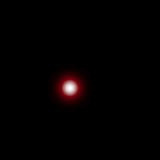


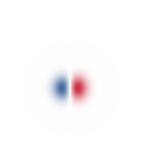


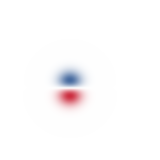


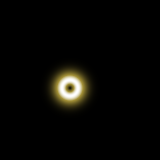

In [ ]:
# Intensity uses the scalar-field color ramp.
show_image(frame.I[0], "Gaussian Blob Intensity")

# Signed derivatives use the diverging ramp so negative and positive values differ.
show_image(gx, "Gaussian Blob Horizontal Gradient", signed=True)
show_image(gy, "Gaussian Blob Vertical Gradient", signed=True)

# Magnitude is nonnegative, so it uses the magnitude ramp.
show_image(gmag, "Gaussian Blob Gradient Magnitude", kind="magnitude")

## Current Generators

Each cell below follows the same pattern. Pick parameters, call one generator, and display the first batch item with a descriptive title. When a new generator is added to the library, the notebook only needs one more cell in this section. The helper functions and color scheme do not need to change.


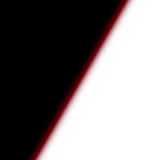

In [ ]:
# Smoothed step creates a single edge with a finite transition width.
frame = smoothed_step(H, W, theta_rad=math.radians(30), sigma_e=4)

# frame.I[0] selects the first item in the batch.
show_image(frame.I[0], "Example Of Smoothed Step Generator")


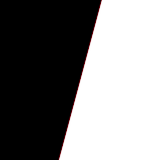

In [ ]:
# Hard step is the discontinuous version of a step edge.
frame = hard_step(H, W, theta_rad=math.radians(15))

show_image(frame.I[0], "Example Of Hard Step Generator")


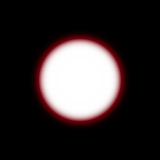

In [35]:
# curved_arc renders a full smoothed circular boundary.
frame = curved_arc(H, W, r0=42, sigma_e=4)

show_image(frame.I[0], "Example Of Smoothed Circular Boundary Generator")


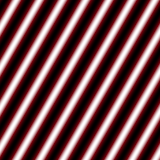

In [38]:
# Sinusoid creates a smooth periodic field with known orientation and frequency.
frame = sinusoid(H, W, freq=0.05, theta_rad=math.radians(30))

show_image(frame.I[0], "Example Of Sinusoid Generator")


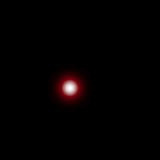

In [37]:
# Gaussian blob creates a localized smooth peak.
frame = gaussian_blob(H, W, sigma=8, x0=-10, y0=8)

show_image(frame.I[0], "Example Of Gaussian Blob Generator")


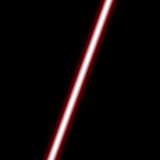

In [36]:
# Gaussian ridge creates a long smooth ridge with a controllable direction.
frame = gaussian_ridge(H, W, sigma=4, theta_rad=math.radians(20))

show_image(frame.I[0], "Example Of Gaussian Ridge Generator")


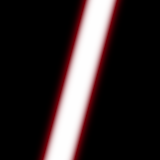

In [39]:
# Smoothed bar creates two nearby smoothed edges around a finite-width region.
frame = smoothed_bar(H, W, width_px=32, theta_rad=math.radians(15), sigma_e=4)

show_image(frame.I[0], "Example Of Smoothed Bar Generator")


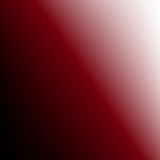

In [40]:
# coeffs has shape (B, degree_y, degree_x). This example uses one batch item.
coeffs = torch.zeros(1, 4, 4)

# Set a few low-order terms so the field has visible tilt and curvature.
coeffs[0, 1, 0] = 0.3
coeffs[0, 0, 1] = -0.2
coeffs[0, 2, 1] = 0.05
coeffs[0, 1, 2] = -0.04

# scale controls the coordinate normalization used by the polynomial.
frame = polynomial(H, W, coeffs=coeffs, scale=64)

show_image(frame.I[0], "Example Of Polynomial Generator")

## A Batch Example

Most generators accept scalar parameters or batched tensor parameters. Tensor parameters make it possible to generate several related fields with one call. The batch dimension appears first in `frame.I` and `frame.g`, so `frame.I[0]`, `frame.I[1]`, and `frame.I[2]` display the three generated examples.


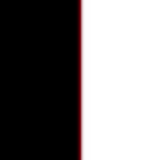


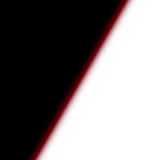


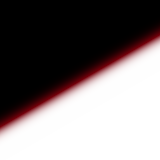

In [41]:
# Tensor parameters create three smoothed steps in one generator call.
frame = smoothed_step(
    H,
    W,
    theta_rad=torch.tensor([0.0, math.radians(30), math.radians(60)]),
    sigma_e=torch.tensor([2.0, 4.0, 6.0]),
)

# Each batch item has the same shape but different edge parameters.
show_image(frame.I[0], "Batched Smoothed Step Item 0")
show_image(frame.I[1], "Batched Smoothed Step Item 1")
show_image(frame.I[2], "Batched Smoothed Step Item 2")